<a href="https://colab.research.google.com/github/charmy-patel/practicals/blob/bigdata/SQLQueries_on_Multiple_partition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Convert RDD data to dataframe to for SQL Query

In [7]:
from pyspark.sql import SparkSession, Row

# Start Spark session
spark = SparkSession.builder.master("local[*]").appName("SalesRDD").getOrCreate()
sc = spark.sparkContext

# Read CSV from Drive
rdd = sc.textFile("/content/drive/MyDrive/Colab Notebooks/sales1.csv")

# Skip header
header = rdd.first()
data_rdd = rdd.filter(lambda line: line != header)

# Split and convert to Row
sales_rdd = data_rdd.map(lambda line: line.split(",")) \
    .map(lambda fields: Row(
        OrderID=int(fields[0]),
        CustomerID=fields[1],
        Product=fields[2],
        Quantity=int(fields[3]),
        Price=float(fields[4]),
        Date=fields[5]
    ))

# Convert to DataFrame
sales_df = spark.createDataFrame(sales_rdd)
sales_df.createOrReplaceTempView("sales")

# Preview
sales_df.show()


+-------+----------+--------+--------+-------+----------+
|OrderID|CustomerID| Product|Quantity|  Price|      Date|
+-------+----------+--------+--------+-------+----------+
|    101|      C001|  Laptop|       2|10000.0|01-07-2025|
|    102|      C002|   Mouse|       3|  500.0|01-07-2025|
|    103|      C001|Keyboard|       4|  600.0|02-07-2025|
|    104|      C003| Monitor|       2| 1000.0|02-07-2025|
|    105|      C001|Keyboard|       3|  600.0|02-07-2025|
|    106|      C003|  Laptop|       4|10000.0|02-07-2025|
|    107|      C002|   Mouse|       5|  500.0|02-07-2025|
|    108|      C001|Keyboard|       1|  600.0|03-07-2025|
|    109|      C002|  Laptop|       2|10000.0|03-07-2025|
|    110|      C001|   Mouse|       3|  500.0|03-07-2025|
|    111|      C003| Monitor|       4| 1000.0|03-07-2025|
|    112|      C001|Keyboard|       2|  600.0|03-07-2025|
|    113|      C003|  Laptop|       3|10000.0|03-07-2025|
|    114|      C002|   Mouse|       4|  500.0|03-07-2025|
|    115|     

Display Partitionwise Row Count

In [9]:
# Count elements per partition
def count_per_partition(index, iterator):
    yield (index, len(list(iterator)))

partition_counts = data_rdd.mapPartitionsWithIndex(count_per_partition).collect()
partition_counts.sort()


# Print partition index and row count
for partition_index, row_count in partition_counts:
    print(f"Partition {partition_index}: {row_count} rows")


Partition 0: 7 rows
Partition 1: 8 rows


Display Partitionwise Data

In [11]:
# Print partition wise data
def inspect(index, iterator):
    yield f"Partition {index}: {list(iterator)}"

for part in rdd.mapPartitionsWithIndex(inspect).collect():
    print(part)


Partition 0: ['OrderID,CustomerID,Product ,Quantity,Price,Date', '101,C001,Laptop,2,10000,01-07-2025', '102,C002,Mouse,3,500,01-07-2025', '103,C001,Keyboard,4,600,02-07-2025', '104,C003,Monitor,2,1000,02-07-2025', '105,C001,Keyboard,3,600,02-07-2025', '106,C003,Laptop,4,10000,02-07-2025', '107,C002,Mouse,5,500,02-07-2025']
Partition 1: ['108,C001,Keyboard,1,600,03-07-2025', '109,C002,Laptop,2,10000,03-07-2025', '110,C001,Mouse,3,500,03-07-2025', '111,C003,Monitor,4,1000,03-07-2025', '112,C001,Keyboard,2,600,03-07-2025', '113,C003,Laptop,3,10000,03-07-2025', '114,C002,Mouse,4,500,03-07-2025', '115,C001,Monitor,1,1000,03-07-2025']


Use SQL Query which fetch data from multiple partitions

In [12]:
# Total revenue per product
spark.sql("""
    SELECT Product, SUM(Quantity * Price) AS TotalRevenue
    FROM sales
    GROUP BY Product
    ORDER BY TotalRevenue DESC
""").show()


+--------+------------+
| Product|TotalRevenue|
+--------+------------+
|  Laptop|    110000.0|
|   Mouse|      7500.0|
| Monitor|      7000.0|
|Keyboard|      6000.0|
+--------+------------+



In [16]:
# SQL: Total revenue per product
revenue_df = spark.sql("""
    SELECT Product, SUM(Quantity * Price) AS TotalRevenue
    FROM sales
    GROUP BY Product
""")

# Convert to Pandas DataFrame
revenue_pd = revenue_df.toPandas()


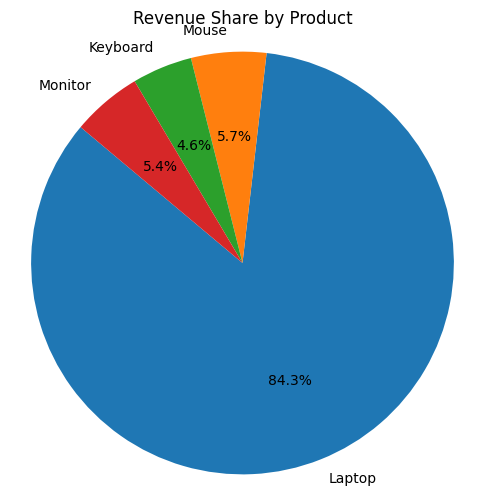

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.pie(revenue_pd['TotalRevenue'], labels=revenue_pd['Product'], autopct='%1.1f%%', startangle=140)
plt.title("Revenue Share by Product")
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle
plt.show()
